In [1]:
import math
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## Data Reading

In [2]:
df = pd.read_csv("../data/raw/Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


We do not have missing values in the dataset, so no need to handle them

In [4]:
unique_values = df.nunique()
unique_values

price               219
area                284
bedrooms              6
bathrooms             4
stories               4
mainroad              2
guestroom             2
basement              2
hotwaterheating       2
airconditioning       2
parking               4
prefarea              2
furnishingstatus      3
dtype: int64

We have 12 features, from which 11 are categorical and "area" numerical

## Visualisation of features

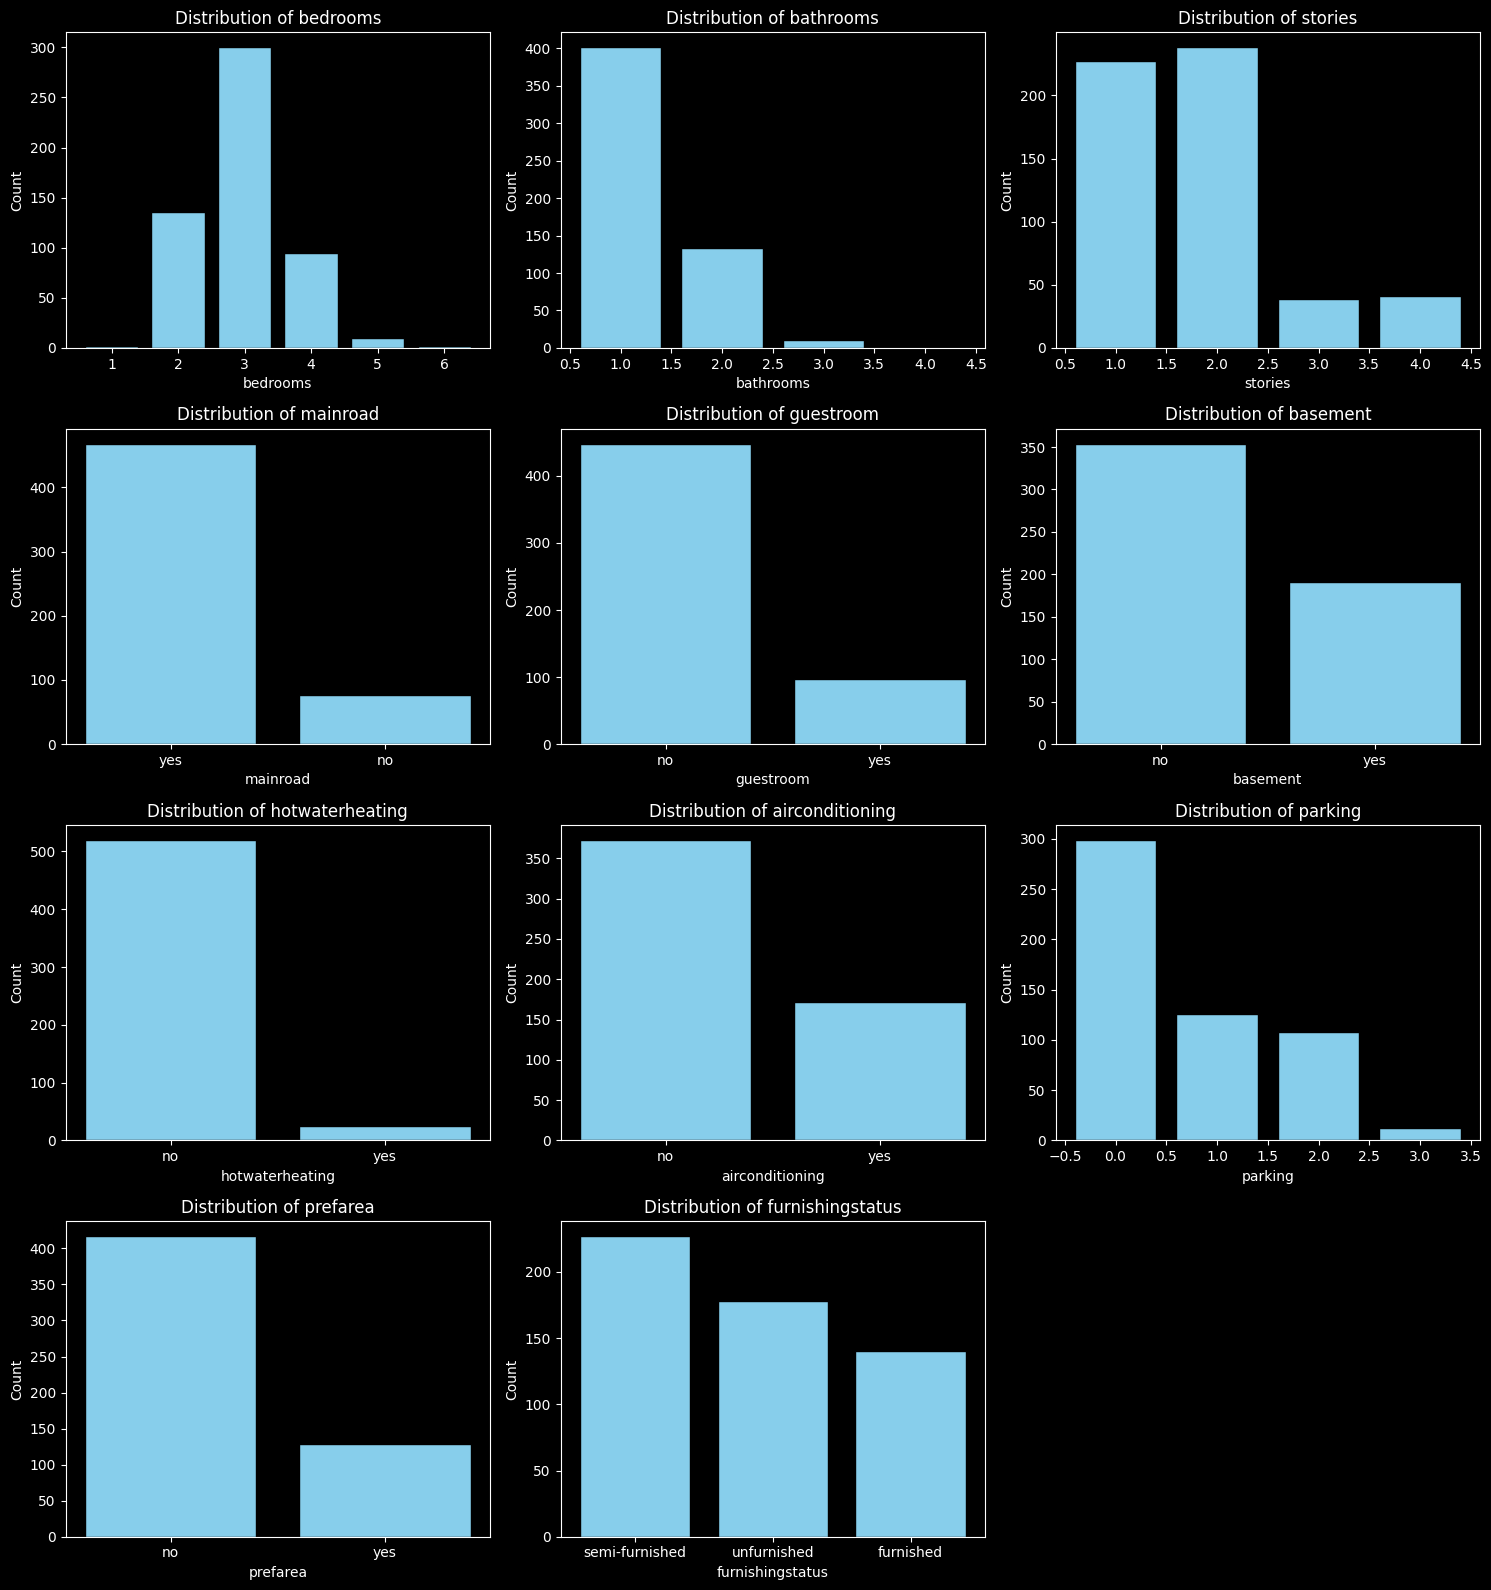

In [5]:
# Exclude target and numerical feature
exclude_cols = ["area", "price"]

# Columns with at most 6 unique values
categorical_cols = [col for col in df.columns if col not in exclude_cols and df[col].nunique() <= 6]

n_cols = 3
n_rows = math.ceil(len(categorical_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))

# Flatten axes array for easy indexing
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values, color='skyblue', edgecolor='black')
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_ylabel("Count")
    axes[i].set_xlabel(col)

# Hide any empty subplots
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

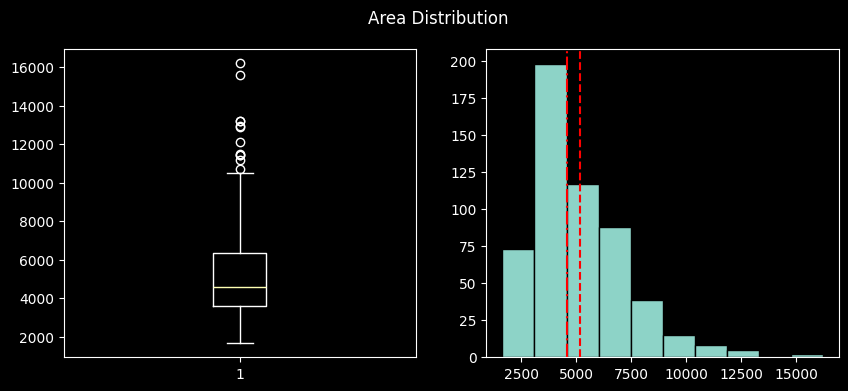

In [6]:
area = df["area"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
# Boxplot of data to detect outliers
axes[0].boxplot(area)
# Data distribution
axes[1].hist(area, edgecolor="black")
axes[1].axvline(area.mean(), linestyle="--", color="red", label="mean")
axes[1].axvline(area.median(), linestyle="-.", color="red", label="median")

fig.suptitle("Area Distribution")
plt.show()

## Remove outliers and duplicate rows

In [7]:
df.drop_duplicates(inplace=True)
Q1 = df["area"].quantile(0.25) # 25% quantile
Q3 = df["area"].quantile(0.75) # 75% quantile

IQR = Q3 - Q1 # Interquantile range

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[df["area"] <= upper]
df = df[df["area"] >= lower]

One hot encoding

In [8]:
cols_to_encode = [col for col in df.columns if col not in exclude_cols and df[col].nunique() > 2]
binary_cols = [col for col in df.columns if col not in exclude_cols and df[col].nunique() == 2]

df_encoded = pd.get_dummies(df, columns=cols_to_encode)
for col in binary_cols:
    df_encoded[col] = df_encoded[col].map({"yes":True, "no":False})

df_encoded

,price,area,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,bedrooms_1,bedrooms_2,...,stories_2,stories_3,stories_4,parking_0,parking_1,parking_2,parking_3,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,True,False,False,False,True,True,False,False,...,False,True,False,False,False,True,False,True,False,False
1,12250000,8960,True,False,False,False,True,False,False,False,...,False,False,True,False,False,False,True,True,False,False
2,12250000,9960,True,False,True,False,False,True,False,False,...,True,False,False,False,False,True,False,False,True,False
3,12215000,7500,True,False,True,False,True,True,False,False,...,True,False,False,False,False,False,True,True,False,False
4,11410000,7420,True,True,True,False,True,False,False,False,...,True,False,False,False,False,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,True,False,True,False,False,False,False,True,...,False,False,False,False,False,True,False,False,False,True
541,1767150,2400,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
542,1750000,3620,True,False,False,False,False,False,False,True,...,False,False,False,True,False,False,False,False,False,True
543,1750000,2910,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,True,False,False


## Data splitting

In [9]:
y = df_encoded["price"]
X = df_encoded.drop(columns=["price"])

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=10)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.15, random_state=10)

print("X_train shape: ", X_train.shape)
print("X_val shape: ", X_val.shape)
print("X_test shape: ", X_test.shape)

X_train shape:  (385, 28)
X_val shape:  (68, 28)
X_test shape:  (80, 28)


In [10]:
scaler = StandardScaler()

# Fit only on training data, then transform all splits

cols_to_scale = ["area"]

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_val[cols_to_scale] = scaler.transform(X_val[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

In [12]:
target_scaler = StandardScaler()
y_train_scaled = target_scaler.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_val_scaled   = target_scaler.transform(y_val.values.reshape(-1, 1)).ravel()
y_test_scaled  = target_scaler.transform(y_test.values.reshape(-1, 1)).ravel()

In [13]:
X_train.to_csv("../data/processed/X_train.csv", index=False)
X_val.to_csv("../data/processed/X_val.csv", index=False)
X_test.to_csv("../data/processed/X_test.csv", index=False)

pd.Series(y_train_scaled).to_csv("../data/processed/y_train.csv", index=False)
pd.Series(y_val_scaled).to_csv("../data/processed/y_val.csv", index=False)
pd.Series(y_test_scaled).to_csv("../data/processed/y_test.csv", index=False)

In [14]:
# Save scaler
joblib.dump(scaler, "../models/scaler.pkl")
joblib.dump(target_scaler, "../models/target_scaler.pkl")

['../models/target_scaler.pkl']